In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure

from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa


class TaylorDiagram:
    """
    Taylor Diagram class for visualizing model performance.
    It compares standard deviation, correlation coefficient, and RMSE between observations and model predictions.
    """

    def __init__(
            self, 
            sd_obs: float = None, 
            fig: Figure=None, 
            position: tuple[int, int, int] = (1, 1, 1), 
            markersize: int = 100, 
            sd_range: tuple[float, float] = (0, 1.5), 
            sd_unit: str = 'ppb',
    ):
        
        """
        Initialize the axis for the Taylor Diagram.

        Args:
            sd_obs (float):
                Observed standard deviation.
                It makes sense to have it only if all markers share the same observed standard deviation.
            fig (Figure):
                Instance of a matplotlib figure. The axis for the Taylor Diagram will be added as as 
                subplot to this figure.
            position (tuple):
                Three integers (nrows, ncols, index). The subplot will take the index position
                on a grid with nrows rows and ncols columns.
            markersize (int):
                Size of the markers.
            sd_range (tuple):
                Two floats (min, max). It indicates the range for the radial coordinate.
            sd_unit (str):
                Unit for the standard deviation. It is only used for the axis label.
        """
   
        self.sd_obs = sd_obs  # Standard deviation of the reference
        self.markersize = markersize
        self.smin = sd_range[0]  # Minimum standard deviation
        self.smax = sd_range[1]  # Maximum standard deviation
        
        # Polar transformation for the Taylor diagram
        tr = PolarAxes.PolarTransform()

        # Correlation coefficient labels and positions
        rlocs = np.concatenate(((np.arange(11.0) / 10.0), [0.95, 0.99]))  # Correlation values
        tlocs = np.arccos(rlocs)  # Convert correlations to polar angles
        gl1 = gf.FixedLocator(tlocs)  # Position of ticks
        tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))  # Format tick labels

        # Define the grid helper with axis limits and labels

        gh = fa.GridHelperCurveLinear(
            tr,
            extremes=(0, np.pi / 2, self.smin, self.smax),  # (theta_min, theta_max, r_min, r_max)
            grid_locator1=gl1,
            tick_formatter1=tf1,
        )

        # Create figure and subplot
        if fig is None:
            fig = plt.figure()
        ax = fa.FloatingSubplot(fig, *position, grid_helper=gh)
        fig.add_subplot(ax)

        # Customize the axes
        # Correlation coefficient axis (top)
        ax.axis['top'].set_axis_direction('bottom')
        ax.axis['top'].label.set_text('Correlation coefficient')
        ax.axis['top'].toggle(ticklabels=True, label=True)
        ax.axis['top'].major_ticklabels.set_axis_direction('top')
        ax.axis['top'].label.set_axis_direction('top')

        # Standard deviation axis (left)
        ax.axis['left'].set_axis_direction('bottom')
        ax.axis['left'].label.set_text('Standard deviation [{}]'.format(sd_unit))
        ax.axis['left'].toggle(ticklabels=True, label=True)
        ax.axis['left'].major_ticklabels.set_axis_direction('bottom')
        ax.axis['left'].label.set_axis_direction('bottom')

        # Standard deviation axis (right)
        ax.axis['right'].set_axis_direction('top')
        ax.axis['right'].label.set_text('Standard deviation [{}]'.format(sd_unit))
        ax.axis['right'].toggle(ticklabels=True, label=True)
        ax.axis['right'].major_ticklabels.set_axis_direction('left')
        ax.axis['right'].label.set_axis_direction('top')

        # Hide bottom axis (not used)
        ax.axis['bottom'].set_visible(False)

        # Draw constant correlation lines
        for angle in tlocs:  # Use tlocs for exact positions of correlation labels
            x = [0, self.smax * np.cos(angle)]  # Line endpoints (x-coordinates)
            y = [0, self.smax * np.sin(angle)]  # Line endpoints (y-coordinates)
            ax.plot(x, y, color='gray', linestyle='--', linewidth=0.5)  # Dashed gray lines

        # Set main axes for plotting
        self._ax = ax  # Main axes
        self.ax = ax.get_aux_axes(tr)  # Polar coordinates

        # Add reference line and RMSE contours
        if self.sd_obs != None:

            # Plot the reference line and point
            l = self.ax.scatter(
                [0], self.sd_obs, color='k', marker='*', s=self.markersize
            )  # Reference point
            t = np.linspace(0, np.pi / 2)  # Angles for sd_obs contour
            r = np.zeros_like(t) + self.sd_obs
            self.ax.plot(t, r, 'k--', label='_')  # Reference sd_obs line

            # Add RMSE countours
            contours = self.add_contours(colors='0.5')
            self.ax.clabel(contours, inline=1, fontsize=10)


    def add_samples(
            self, 
            sds: list[float], 
            pearsons: list[float], 
            label: str, 
            *args, 
            **kwargs
        ):

        """
        Add markers representing sample points to the Taylor diagram.

        Args:
            sd_obs (list of floats):
                Standard deviations of the sample points
            pearsons (list of floats):
                Pearson's correlation coefficiens of the sample points 
            *args, **kwargs: Additional plotting parameters (e.g., color, marker).
        """
        
        self.ax.scatter(
            np.arccos(pearsons), sds, s=self.markersize, zorder=10, label=label, *args, **kwargs
        )  # Plot in polar coordinates


    def add_contours(
            self, 
            levels: int = 10, 
            **kwargs
        ):

        """
        Add RMSE contours to the Taylor diagram.

        Args:
            levels (int):
                Number of contour levels
            **kwargs: Additional contour parameters.
        """

        rs, ts = np.meshgrid(
            np.linspace(self.smin, self.smax),
            np.linspace(0, np.pi / 2),
        )
        xs = rs * np.cos(ts)
        ys = rs * np.sin(ts)
        rmse = np.sqrt(
            self.sd_obs**2
            + rs**2
            - 2 * self.sd_obs * rs * np.cos(ts)
        )
        contours = self._ax.contour(xs, ys, rmse, levels=levels, **kwargs)
        return contours

In [29]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxy.config import set_print_settings
from fluxy.io import read_config_files

### Path to results directory 
data_dir = '/capstor/store/cscs/userlab/s1302/dbritome/test_data_for_Joel'

### Set presentation_mode to True for bigger fonts
presentation_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['InTEM_NAME_EUROPE_EDGAR_std','ELRIS_NAME_EUROPE_EDGAR_std','RHIME_NAME_EUROPE_EDGAR_std'],
               'wetcharts'     :['InTEM_NAME_EUROPE_EDGARWETCHART_31sites_std','ELRIS_NAME_EUROPE_EDGARWETCHART_31base',
                                 'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_std_31sites'],
               # 'n2o': ['ELRIS_NAME_EUROPE_EDGAR_28sites', 'ELRIS_FLEXPART_EUROPE_EDGAR_28sites', 'CIF-EnKS_ICON-ART_EUROPE_TNO-AVENGERS']
               'n2o': ['CIF-EnKS_ICON-ART_EUROPE_TNO-AVENGERS', 'ELRIS_NAME_EUROPE_EDGAR_28sites']
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [30]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_mf
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'n2o' 
site = 'MHD'
models = experiments['n2o']
period = 'monthly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppb'
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
get_labels_from_file = False # If False, uses default labels. If True, uses labels from config file.
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              mf_units_print=mf_units_print)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

In [31]:
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import numpy as np
from fluxy import config
import pandas as pd
from typing import Literal


def plot_taylor_diagram(
    stats: dict[Literal['prior', 'posterior'], pd.DataFrame],
    model_colors: dict[str, str],
    model_labels: dict[str, str],
    plot_type_model: Literal['separate', 'together'] = 'separate',
    plot_type_stat: Literal['separate', 'together'] = 'separate',
    include: list[str] = ['prior', 'posterior'],
    sd_range: tuple[float, float] = (0, 2.5),
    sd_unit: str = 'ppb',
) -> Figure:
    """
    Plots statistics for all sites, for all models.

    Args:
        stats (pandas.DataFrame):
            Statistical measures, for each site and for each model.
        stats_to_plot (list of str):
            Statistical measures to plot.
        species (str):
            Gas species, e.g. 'ch4'.
        model_colors (dict of str):
            Models and corresponding colours used to plot the model.
        model_labels (dict of str):
            Models and corresponding labels used to plot the stats.
        config_data (dict of dict):
            Dictionary with settings read from json file.
            Use json filenames as keys.
        mf_units_print (str):
            Mole fraction units used in plots
        stats_type (str):
            Type of statistics to be plotted. Should be the same as used in call to stats_mf().
        stats_ylim (dict of lists):
            Limits for y-axis of individual statistic plots. Can be given for selected
            statistics only or passed as None for automatic axis range.
        start_date (str) and end_date (str):
            Dates used to title the plot.
    Returns:
        fig (figure):
            Plot showing each model's fit statistics, for each site.
    """

    models = np.unique(stats[include[0]]['model'].to_numpy())

    # Set the number of rows and columns
    NCOLS_MAX = 3
    ncols = nrows = 1

    if plot_type_model != 'together' or plot_type_stat != 'together':

        if plot_type_model == 'separate' and plot_type_stat == 'separate':
            nsubplots = (len(models) * len(stats))

        elif plot_type_model == 'together' and plot_type_stat == 'separate':
            nsubplots = len(stats)

        elif plot_type_model == 'separate' and plot_type_stat == 'together':
            nsubplots = len(models)

        ncols = NCOLS_MAX if nsubplots >= NCOLS_MAX else nsubplots
        nrows = nsubplots // ncols + 1
    
    # Create the figure
    fig = plt.figure(figsize=(6 * ncols, 6 * nrows), tight_layout=False)

    # Create a dictionary to save positions of diagrams
    dict_diags_pos = {}

    # Loop over statistics (i.e., prior, posterior)
    for i, (s, stat) in enumerate(stats.items()):
        long_stat = pd.melt(stat, id_vars=['model', 'site'], value_vars=['pearson', 'sd_obs', 'sd_sim'])
        df_pearson = long_stat[long_stat['variable'] == 'pearson'].pivot(index='site', columns='model', values='value')
        df_sds_obs = long_stat[long_stat['variable'] == 'sd_obs'].pivot(index='site', columns='model', values='value')
        df_sds_sim = long_stat[long_stat['variable'] == 'sd_sim'].pivot(index='site', columns='model', values='value')

        # Loop over models
        for j, m in enumerate(models):
            
            # Get the position of the subplot depending on the case
            if plot_type_model == 'separate' and plot_type_stat == 'separate':
                index_pos = i * ncols + j + 1

            elif plot_type_model == 'together' and plot_type_stat == 'together':
                index_pos = 1

            elif plot_type_model == 'together' and plot_type_stat == 'separate':
                index_pos = i + 1

            elif plot_type_model == 'separate' and plot_type_stat == 'together':
                index_pos = j + 1

            # Get the statistics for the model m
            list_sds_obs = df_sds_obs[m].values
            list_sds_sim = df_sds_sim[m].values
            list_pearsons = df_pearson[m].values

            # Remove observation reference if multiple sd_obs
            sd_obs = df_sds_obs[m].values[0] if len(list_sds_obs) == 1 else None

            # Create the Taylor diagram using the corresponding class or fetch it
            if index_pos not in dict_diags_pos:
                diag = TaylorDiagram(
                    sd_obs=sd_obs, 
                    fig=fig, 
                    position=(nrows, ncols, index_pos),
                    markersize=150, 
                    sd_range=sd_range, 
                    sd_unit=sd_unit
                )

            else:
                diag = dict_diags_pos[index_pos]

            # Define labels, colors and markers
            label = model_labels[m] + ' - ' + s
            color = model_colors[m][0] if s == 'prior' else model_colors[m][1] 
            marker = 'o' if s == 'prior' else 's'

            # Add samples to the diagram
            diag.add_samples(list_sds_sim, list_pearsons, c=color, edgecolor='k', marker=marker, label=label)
            diag._ax.legend(fontsize=10, loc='lower left', bbox_to_anchor=(0.1, 1.05))

            # Save the position of the diagram's subplot
            dict_diags_pos[index_pos] = diag

    return fig

/tmp/ipykernel_216607/3468210233.py:53: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()
/tmp/ipykernel_216607/3468210233.py:53: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()


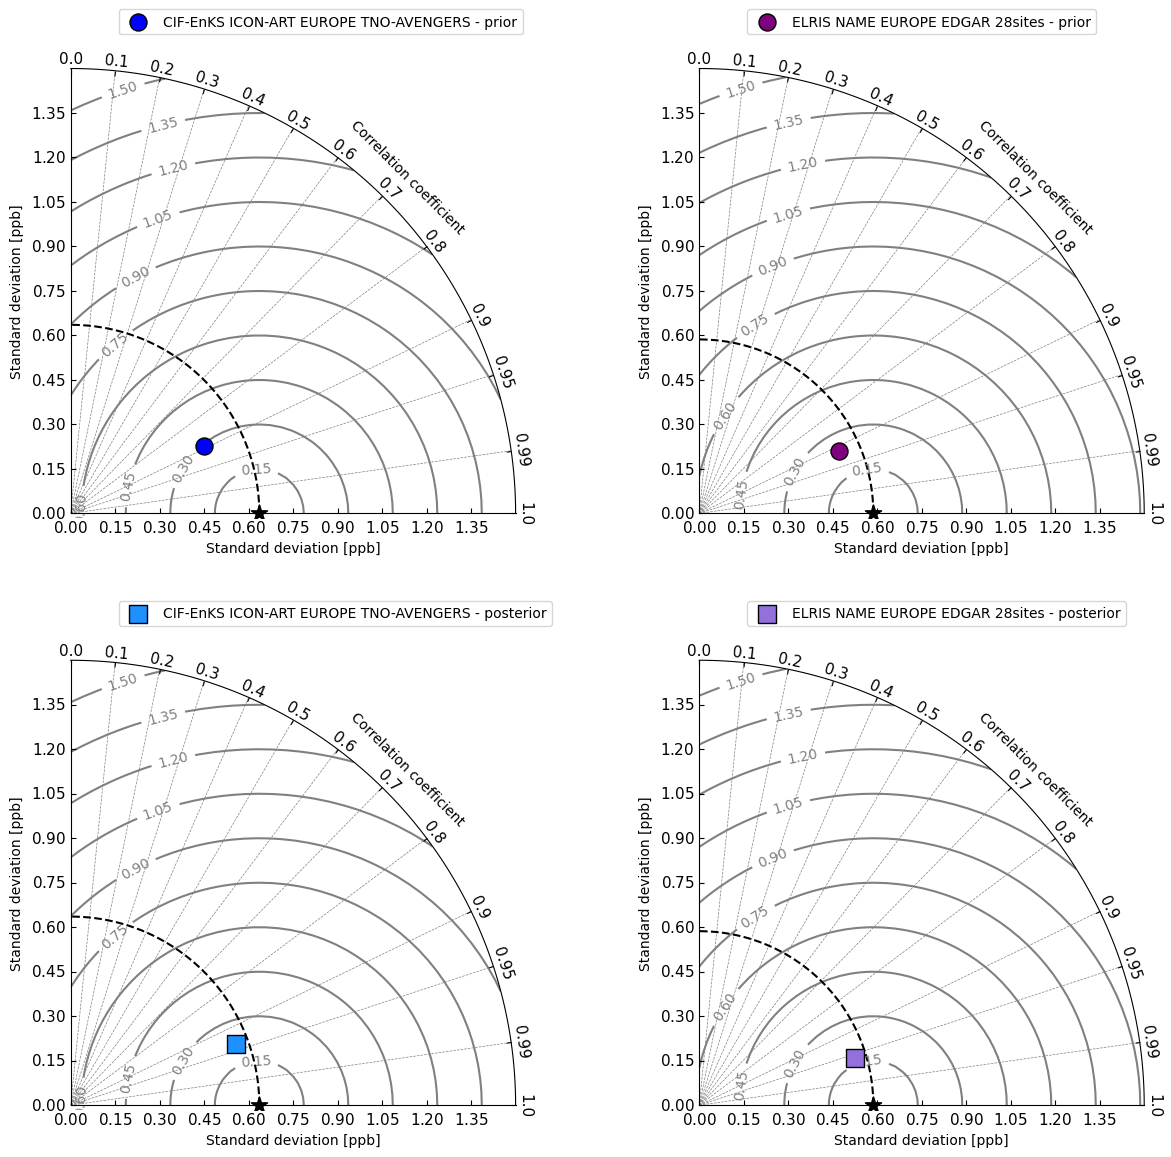

In [32]:
from fluxy.operators.select import slice_mf
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf

###################################
ds_all_allsites = slice_mf(
    ds_all_mf.copy(),
    start_date,
    end_date,
    site="MHD",
    baseline_site=baseline_site,
    data_dir=data_dir,
    mf_units_print=mf_units_print,
)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

stats_prior = stats_mf(ds_all_allsites, stats_type="prior")
stats_posterior = stats_mf(ds_all_allsites, stats_type="posterior")

fig = plot_taylor_diagram(
    stats={'prior': stats_prior, 'posterior': stats_posterior},
    model_colors=model_colors,
    model_labels=model_labels,
    plot_type_model='separate',
    plot_type_stat='separate',
    include=['prior', 'posterior'],
    sd_range=[0, 1.5],
    sd_unit='ppb'
)

fig.show()